In [1]:
import os
print("Current Working Directory:")
print(os.getcwd())

import os

os.chdir(r"C:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis")

print(os.getcwd())
print(os.listdir("data"))



Current Working Directory:
c:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis\classification
C:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis
['train.csv']


Training Random Forest and tuning hyperparameters... Please wait.

--- Random Forest Model Evaluation ---
Best Parameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Accuracy:  0.1950
Precision: 0.2022
Recall:    0.1950
F1 Score:  0.1957

Classification Report:
               precision    recall  f1-score   support

           1       0.19      0.18      0.18       124
           2       0.15      0.21      0.17       101
           3       0.25      0.16      0.20       129
           4       0.20      0.21      0.21       123
           5       0.21      0.22      0.21       123

    accuracy                           0.20       600
   macro avg       0.20      0.20      0.19       600
weighted avg       0.20      0.20      0.20       600



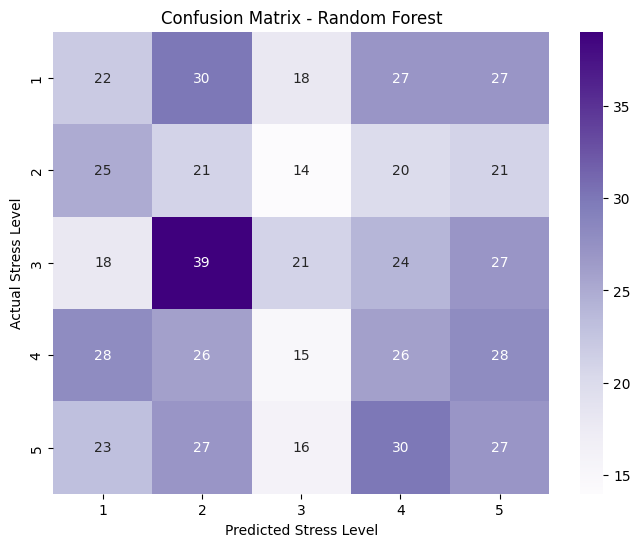

C:\Users\vinay kumar\AppData\Local\Temp\ipykernel_24032\87384882.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


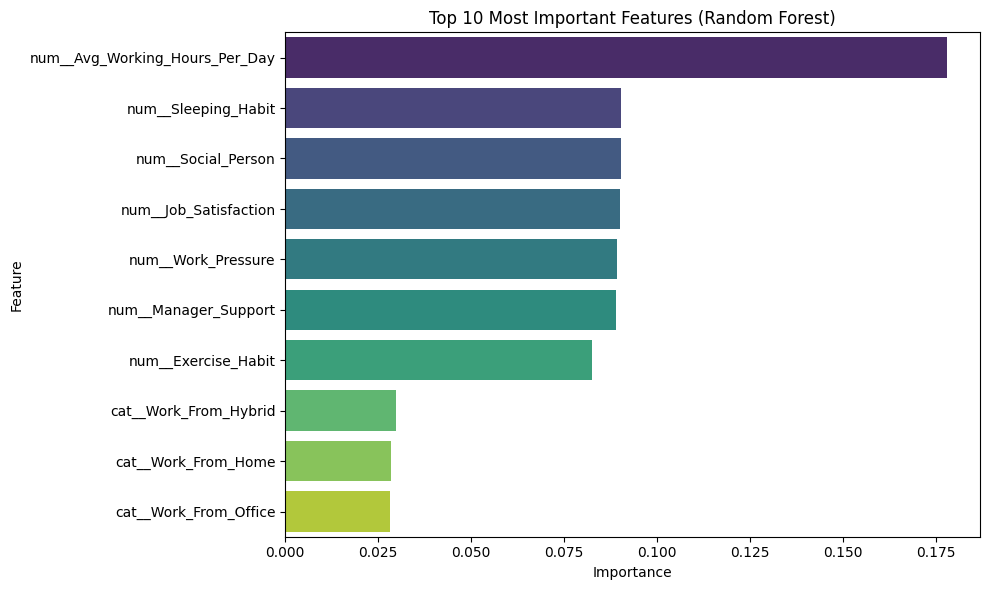

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)


file_path = "train.csv" 
df = pd.read_csv("data/train.csv")


X = df.drop(columns=['Employee_Id', 'Stress_Level'])
y = df['Stress_Level']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

categorical_cols = X_train.select_dtypes(include=['object', 'string']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])


pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# n_estimators: Number of trees in the forest
# max_depth: Maximum depth of each tree
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5]
}

print("Training Random Forest and tuning hyperparameters... Please wait.")
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best model
best_model = grid_search.best_estimator_


y_pred = best_model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print(f"\n--- Random Forest Model Evaluation ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted Stress Level')
plt.ylabel('Actual Stress Level')
plt.title('Confusion Matrix - Random Forest')
plt.show()


# Find out which features the Random Forest relied on the most
importances = best_model.named_steps['classifier'].feature_importances_
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

feature_importance_df = pd.DataFrame({
    'Feature': feature_names, 
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.tight_layout()
plt.show()